## Notebook 1: RNA-Seq Preprocessing and Quality Control

This notebook is the first step in our pipeline. The goal is to take the raw gene count data, perform essential quality control checks, filter out uninformative genes, and apply normalisation and scaling to prepare the data for downstream analysis.

---
## Data Source

The dataset used in this project is a publicly available breast cancer cohort from the Gene Expression Omnibus (GEO).

* **Study**: Sweden Cancerome Analysis Network - Breast (SCAN-B)
* **GEO Accession**: [GSE202203](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE202203)
* **Description**: The dataset contains raw RNA-sequencing counts from 3,207 primary breast tumour samples.

---

### Installing Required Libraries

Before we begin, we first need to install the `conorm` library. This is a specialised Python package that provides several simple normalisation techniques that are frequently used in the analysis of RNA expression data.

In [1]:
# pip install conorm

### Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import conorm
from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Uploading Your Own RNA-Seq Data
By default, this notebook loads the GSE202203 dataset obtained from GEO Omnibus.
To use your own dataset:

1. Save your file in .tsv format (tab-delimited).

2. Ensure the structure matches the expected format:
    - Rows = Gene identifiers
    - Columns = Sample IDs
    - Values = Numeric raw counts

3. Update the counts_path variable in the code cell below with your file name or path.
4. Update the sep argument in pd.read_csv() accordingly:
    - .tsv → sep="\t"
    - .csv → sep=","
5. The notebook will automatically read and preview the data.

Incorrect formatting (e.g., missing gene IDs, non-numeric values) will cause errors in downstream steps.



In [3]:
# Path to raw_counts matrix
counts_path = "GSE202203_RawCounts_gene_3207.tsv"

# Load the dataset (genes as rows, samples as columns)
df = pd.read_csv(counts_path, sep="\t", index_col=0)

# Preview: first 10 rows and first 8 columns (not sorted, just a general look)
df.iloc[:10, :8]

,S000001,S000002,S000003,S000006,S000008,S000011,S000012,S000013
X,,,,,,,,
A1BG,412.358202,105.952180,157.582677,104.325878,145.012995,201.812885,289.173348,23.331057
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2M,23884.926531,7526.736567,30855.152448,36483.893945,17015.951039,23280.069420,10460.446135,29668.790548
A2ML1,1.426652,404.546684,163.826684,140.628321,0.000000,0.000000,822.440140,444.348836
A3GALT2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A4GALT,2836.330202,274.625857,549.653372,306.256495,615.226716,229.400197,111.130124,145.613354
A4GNT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AAAS,976.445204,378.742855,1198.252831,906.179373,564.519679,690.157621,1248.170207,530.693321
AACS,2161.033619,564.993344,2299.233003,1059.479951,930.486799,631.733326,2288.100219,538.393320


In [4]:
# Shape and preview
print(f"raw_counts matrix shape: {df.shape} (genes x samples)")

raw_counts matrix shape: (19644, 3207) (genes x samples)


### Converting the raw inputs into integers

We are converting our data to integers simply because RNA-seq data represents gene "counts." You cannot have half a read, so the data should be whole numbers.

More importantly, statistical tools like **edgeR** are built specifically for count data and require integers to work correctly.

In [5]:
df = df.round().astype(int)
df.iloc[:10, :8]

,S000001,S000002,S000003,S000006,S000008,S000011,S000012,S000013
X,,,,,,,,
A1BG,412,106,158,104,145,202,289,23
A1CF,0,0,0,0,0,0,0,0
A2M,23885,7527,30855,36484,17016,23280,10460,29669
A2ML1,1,405,164,141,0,0,822,444
A3GALT2,0,0,0,0,0,0,0,0
A4GALT,2836,275,550,306,615,229,111,146
A4GNT,0,0,0,0,0,0,0,0
AAAS,976,379,1198,906,565,690,1248,531
AACS,2161,565,2299,1059,930,632,2288,538


### Quality Check: Exploring Zero Counts

Before preprocessing our data, it's important to understand its basic properties.
A key first step is to check for zero values, which indicate that a gene's expression was not detected in a sample. 

The following code performs a quick quality control check to get a sense of the dataset's overall sparsity by calculating the percentage of zeros. It also identifies any uninformative genes that have zero expression across all samples, as well as any failed samples that show no gene expression at all, both of which will need to be filtered out.

In [6]:
# --- 1. Total number of zero values ---
total_zeros = (df == 0).sum().sum()
total_values = df.size
zero_percentage = (total_zeros / total_values) * 100

print(f"Total values: {total_values:,}")
print(f"Total zero values: {total_zeros:,}")
print(f"Percentage of zeros: {zero_percentage:.2f}%\n")

# --- 2. Zeros per gene (row-wise) ---
zeros_per_gene = (df == 0).sum(axis=1)

# --- 3. Zeros per sample (column-wise) ---
zeros_per_sample = (df == 0).sum(axis=0)

Total values: 62,998,308
Total zero values: 11,542,688
Percentage of zeros: 18.32%



In [7]:
# How many samples have zero expression for each gene ?
gene_zero_counts = (df == 0).sum(axis=1)

# How many genes have zero counts in all 3207 samples ?
all_zero_genes = (gene_zero_counts == df.shape[1]).sum()

print(f"Number of genes (rows) with all-zero expression across all {df.shape[1]} samples: {all_zero_genes}")

Number of genes (rows) with all-zero expression across all 3207 samples: 64


In [8]:
# Which samples (columns) have all-zero values
all_zero_samples = (df == 0).all(axis=0)

# Count them
num_all_zero_samples = all_zero_samples.sum()

print(f"Number of samples (columns) with all-zero expression: {num_all_zero_samples}")

Number of samples (columns) with all-zero expression: 0


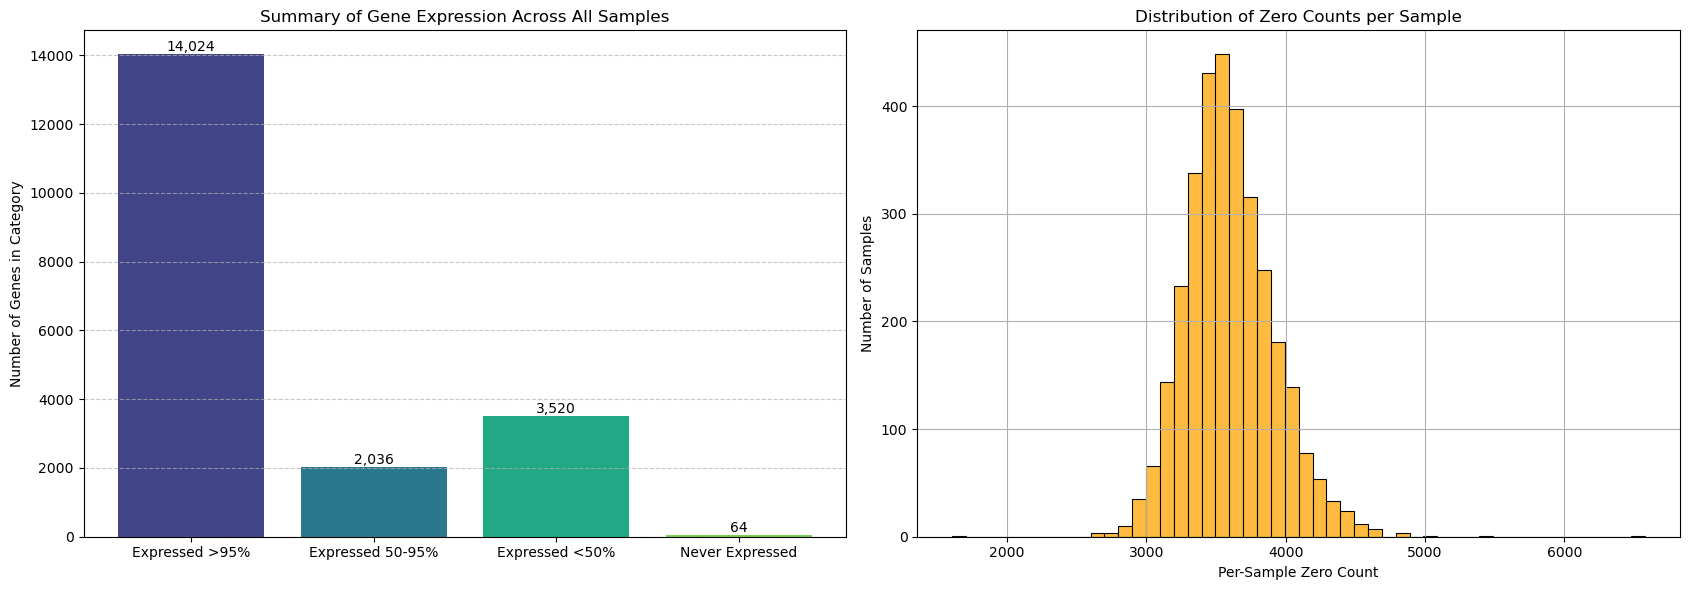

In [9]:
# To create the side-by-side figure 
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Plot 1 (Left): gene summary across samples
num_samples = df.shape[1]

cat1_count = (zeros_per_gene < num_samples * 0.05).sum()
cat2_count = ((zeros_per_gene >= num_samples * 0.05) & (zeros_per_gene < num_samples * 0.5)).sum()
cat3_count = (zeros_per_gene >= num_samples * 0.5).sum() - all_zero_genes
cat4_count = all_zero_genes

categories = ['Expressed >95%', 'Expressed 50-95%', 'Expressed <50%', 'Never Expressed']
counts = [cat1_count, cat2_count, cat3_count, cat4_count]
colours = sns.color_palette("viridis", n_colors=4)

bar_plot = axes[0].bar(categories, counts, color=colours)
axes[0].set_ylabel('Number of Genes in Category')
axes[0].set_title('Summary of Gene Expression Across All Samples')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels for the bar chart
for bar in bar_plot:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center')


# Plot 2 (Right): Zero Counts per sample
sns.histplot(zeros_per_sample, bins=50, kde=False, color='orange', ax=axes[1])
axes[1].set_title("Distribution of Zero Counts per Sample")
axes[1].set_xlabel("Per-Sample Zero Count")
axes[1].set_ylabel("Number of Samples")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Analysing Zero Count Distributions

1. Graph 1 (Left): Summary of Gene Expression:

    This bar chart provides a summary of how widely our genes are expressed across all patient samples. The vast majority of genes Expressed in more than 95% of the samples, confirming that most genes are reliably detected. The other categories show that very few genes are expressed intermittently, and the "Never Expressed" bar confirms the number of uninformative genes that will be removed.

2. Graph 2 (Right): Zeros per Sample

    To assess the sparsity of gene expression across the cohort, we calculated the number of genes with zero expression in each of the 3,207 tumour samples. The results show that all samples behave similarly. On average, each sample contained around 3,500 genes with zero counts.

---

### Filtering Low-Expression Genes

The next step in our quality control process is to filter out genes that have very low counts, as these are often not biologically significant and can add noise to our analysis.

We will keep a gene only if it is expressed with a certain minimum count in a minimum percentage of our samples. The function below allows us to set these two thresholds to create a cleaner, more reliable dataset for our downstream analysis.

The function below handles this filtering for us, creating a cleaner, more reliable dataset for downstream analysis.

### How the Function Works

By wrapping this logic in a function, we can easily reuse it to test different filtering strategies without rewriting code. It takes two main arguments:

* **`count_threshold`**: The minimum number of reads a gene must have in a sample to be considered 'expressed'. We've set the default to 1.
* **`sample_percentage`**: The minimum fraction of samples that must meet that count threshold. For example, the default of `0.1` means we only keep genes that are expressed in at least 10% of all patient samples.

You can easily call the function again with stricter or more lenient values to see how it affects your dataset.

In [10]:
def filter_genes(df, count_threshold=1, sample_percentage=0.1):
    """
    Filters out genes that do not have a minimum count in a minimum percentage of samples.
    
    Args:
        df (pd.DataFrame): The raw count matrix (genes as rows, samples as columns).
        count_threshold (int): The minimum count to be considered 'expressed'.
        sample_percentage (float): The minimum percentage of samples where the gene must be expressed.
        
    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # Calculate the minimum number of samples based on the percentage
    min_samples = int(sample_percentage * df.shape[1])
    
    # Filter genes that have a count >= threshold in at least min_samples
    genes_to_keep = (df >= count_threshold).sum(axis=1) >= min_samples
    filtered_df = df[genes_to_keep]
    
    num_removed = df.shape[0] - filtered_df.shape[0]
    
    print(f"Filtering with a count of {count_threshold} in at least {sample_percentage*100:.0f}% of samples...")
    print(f"Original shape: {df.shape}")
    print(f"Filtered shape: {filtered_df.shape}")
    print(f"Genes removed: {num_removed:,}")
    
    return filtered_df

In [11]:
# Example of how to use the function with the loaded data:
filtered_df = filter_genes(df, count_threshold=10, sample_percentage=0.1)

Filtering with a count of 10 in at least 10% of samples...
Original shape: (19644, 3207)
Filtered shape: (16374, 3207)
Genes removed: 3,270


In [12]:
# Shape and preview
print(f"raw_counts matrix shape after filtering lowly expressed genes: {filtered_df.shape} (genes x samples)")

raw_counts matrix shape after filtering lowly expressed genes: (16374, 3207) (genes x samples)


### Exporting Filtered Raw Counts for Analysis

Now that we have filtered out the uninformative genes, we will save this clean dataset. The code below exports our filtered raw count data to a tab-separated value (TSV) file.

This file will serve as the primary input for our next notebook, `02_Differential_Expression_Analysis.ipynb`. It contains the essential raw count data that specialised tools require. For our analysis, we will use libraries like `inmoose`, which ports the functionality of established R packages such as `edgeR` into Python.

In [13]:
# Define the file path for your filtered raw count data
output_path = 'filtered_raw_counts.tsv'

# Export the DataFrame to a TSV file
filtered_df.to_csv(output_path, sep='\t', index=True)

print(f"Filtered raw counts successfully exported to {output_path}")

Filtered raw counts successfully exported to filtered_raw_counts.tsv


### Data Normalisation

To compare gene expression between samples, we must first normalise the data. This crucial step corrects for technical variations, such as differences in sequencing depth (library size), ensuring a fair comparison.

For this, we will use conorm, a Python library that conveniently provides several standard normalisation methods used in bioinformatics, including TMM and MRN.

In [14]:
def apply_normalisation(data, method='TMM'):
    """
    Applies selected normalisation method using conorm.
    Supported methods: TMM, MRN, CPM, TotalCount, Percentile, Quartile
    """
    method = method.lower()
    
    if method == 'tmm':
        return conorm.tmm(data)
    elif method == 'mrn':
        return conorm.mrn(data)
    elif method == 'cpm':
        return conorm.cpm(data)
    elif method == 'total':
        return conorm.total_count(data)
    elif method == 'percentile':
        return conorm.percentile(data)
    elif method == 'quartile':
        return conorm.quartile(data)
    else:
        raise ValueError(f"Method '{method}' is not supported.")

### Normalisation Method Selection

You can choose from various RNA-seq normalisation methods supported by the `conorm` package:

- **TMM** (Trimmed Mean of M-values)
- **MRN** (Median Ratio Normalisation)
- **CPM** (Counts Per Million)
- **TPM** - Transcripts Per Million (requires gene lengths)
- **RPK** - Reads Per Kilobase (requires gene lengths)
- **RPKM** - RPK scaled by library size (also requires gene lengths)
- **Total Count** - basic library size adjustment
- **Percentile / Quartile** - also normalisation

Use the `apply_normalisation()` function to apply your selected method:

```python
df_normalised = apply_normalisation(filtered_df, method='TMM')

If your method requires gene lengths (like TPM or RPKM), you can pass them as:

df_normalised = conorm.tpm(filtered_df, gene_lengths)



In [15]:
df_tmm = apply_normalisation(filtered_df, method='TMM')

In [16]:
print(f"Normalised matrix shape: {df_tmm.shape} (genes x samples)")
df_tmm.iloc[:10, :8]

Normalised matrix shape: (16374, 3207) (genes x samples)


,S000001,S000002,S000003,S000006,S000008,S000011,S000012,S000013
X,,,,,,,,
A1BG,428.484796,96.194915,162.710286,110.516551,154.088297,194.678229,262.647578,22.319746
A2M,24840.678018,6830.746443,31774.847241,38770.056141,18082.527367,22436.184022,9506.206471,28791.501486
A2ML1,1.040012,367.537174,168.889157,149.834939,0.000000,0.000000,747.046053,430.868134
A4GALT,2949.473011,249.562279,566.396564,325.173697,653.546916,220.699577,100.878482,141.681864
AAAS,1015.051361,343.942195,1233.714698,962.769183,600.413021,664.989990,1134.201307,515.294998
AACS,2247.465154,512.737045,2367.537638,1125.356032,988.290459,609.092281,2079.369064,522.087964
AADAC,0.000000,11.797490,1.029812,0.000000,0.000000,5.782522,7.270521,19.408474
AADAT,50.960570,31.762472,27.804922,48.882321,8.501423,19.275072,53.620094,86.367711
AAED1,314.083515,187.852333,311.003204,399.559837,193.407380,223.590837,76.340473,476.478049


In [17]:
# # Basic summary
# print("Basic summary (across samples):")
# print(df_tmm.describe())

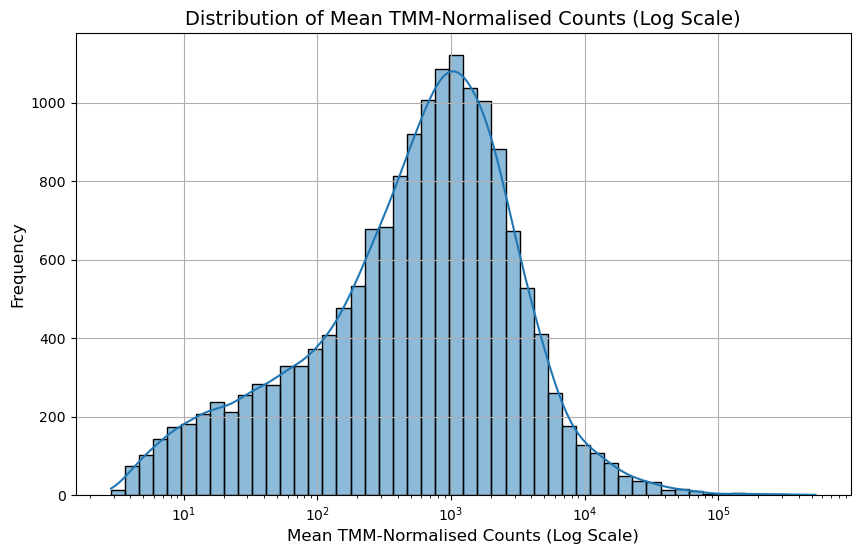

In [18]:
# plotting the distribution of the mean expression of each gene
gene_means = df_tmm.mean(axis=1)

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    gene_means, 
    bins=50, 
    kde=True,
    log_scale=True  # To view the data properly
)

plt.title('Distribution of Mean TMM-Normalised Counts (Log Scale)', fontsize=14)
plt.xlabel('Mean TMM-Normalised Counts (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

### Analysing the Normalised Data Distribution

This plot shows the distribution of our normalised gene counts viewed on a log scale, which helps to reveal the data's underlying structure.

The graph is not symmetrical and shows a clear left-skew. This means the bulk of our genes are concentrated at the higher expression values (the peak on the right), with a long tail of lower-expression genes stretching to the left. This skewness is the reason we need to apply a log-transformation as our next step, to make the data more suitable for analyses like PCA.

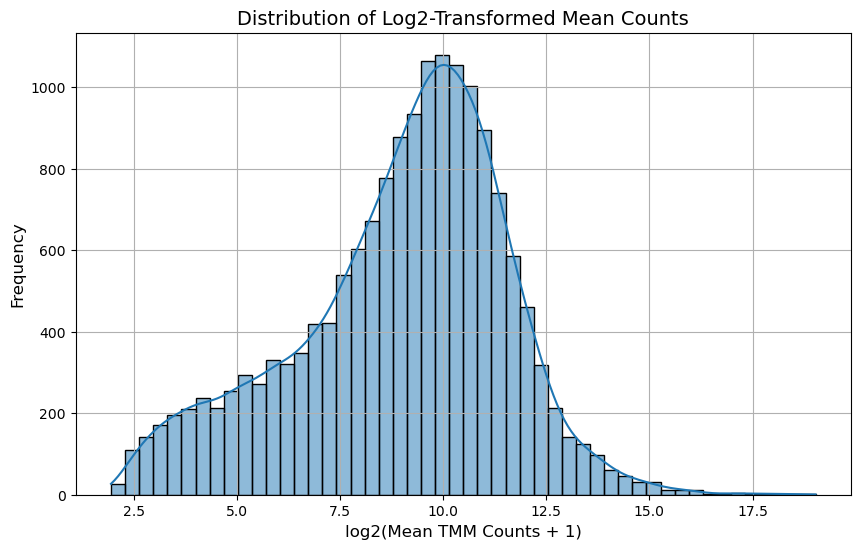

In [19]:
# distribution of the mean expression of each gene
gene_means = df_tmm.mean(axis=1)

# Apply log2 transformation to the mean values
# We add 1 to avoid taking the log of zero (log(0) is undefined)
log2_gene_means = np.log2(gene_means + 1)

# Create the histogram of the log2-transformed means
plt.figure(figsize=(10, 6))
sns.histplot(log2_gene_means, bins=50, kde=True)

plt.title('Distribution of Log2-Transformed Mean Counts', fontsize=14)
plt.xlabel('log2(Mean TMM Counts + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

### Final Data Preparation for PCA

Before running Principal Component Analysis (PCA), we perform three sequential preparation steps. The code below combines these steps to create our final, analysis-ready dataset.

1. Log Transformation:
We first apply a `log2(x+1)` transformation to the entire TMM-normalised dataset. This corrects the left skew in our count data, making its distribution more symmetrical.

2. Data Transposition:
Next, we transpose the data frame using `.T`. This is a technical step to flip the data so that rows represent our patient samples and columns represent our genes, which is the required input format for the `scikit-learn` library.

3. Standard Scaling:
Finally, we apply `StandardScaler`. This crucial step scales every gene to have a mean of 0 and a standard deviation of 1. This ensures that all genes contribute equally to the analysis, preventing genes with high expression values from unfairly dominating the result. The `.fit_transform()` method efficiently learns these scaling parameters and applies the transformation in one go.

The resulting `df_scaled` DataFrame is now fully prepared for Principal Component Analysis.

In [20]:
# Applying log2 transformation:
# We add 1 to avoid taking the log of zero (log(0) is undefined)
df_log2 = np.log2(df_tmm + 1)

# Transpose the DataFrame to have samples as rows and genes as columns
df_for_pca = df_log2.T

# Initialise the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_data = scaler.fit_transform(df_for_pca)

# Convert the scaled data back to a DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df_for_pca.columns, index=df_for_pca.index)

print("Scaled DataFrame shape:", df_scaled.shape)
print("\nFirst 5 rows of the scaled data:")
print(df_scaled.head())

Scaled DataFrame shape: (3207, 16374)

First 5 rows of the scaled data:
X            A1BG       A2M     A2ML1    A4GALT      AAAS      AACS     AADAC  \
S000001  0.696056 -0.055820 -0.405865  2.072324  0.110659  0.629850 -0.601306   
S000002 -1.262109 -2.170047  1.854555 -1.469523 -2.874450 -1.959097  1.425520   
S000003 -0.575004  0.347364  1.517707 -0.295591  0.649254  0.721086 -0.038443   
S000006 -1.080963  0.673221  1.465962 -1.090748 -0.035314 -0.582401 -0.601306   
S000008 -0.646305 -0.575837 -0.715988 -0.090371 -1.338364 -0.809950 -0.601306   

X           AADAT     AAED1     AAGAB  ...    ZWILCH     ZWINT      ZXDA  \
S000001  0.000090  0.416643  0.373920  ... -0.088904 -1.257953  0.053700   
S000002 -0.428617 -0.607306 -3.316423  ... -0.122472 -0.041222 -1.508839   
S000003 -0.548284  0.396990 -0.171397  ...  0.285417  0.512131 -0.212124   
S000006 -0.037853  0.896790 -0.990155  ...  1.035454 -0.851954 -2.292372   
S000008 -1.579245 -0.549314 -1.210347  ... -1.265810 -0.85192

In [21]:
# Define the file path for your preprocessed data
output_path = 'preprocessed_rna_seq_data.tsv'

# Export the DataFrame to a TSV file
df_scaled.to_csv(output_path, sep='\t', index=True)

print(f"Data successfully exported to {output_path}")

Data successfully exported to preprocessed_rna_seq_data.tsv
